# 导入数据

In [16]:
import pandas as pd

url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/Advertising.csv"

df = pd.read_csv(url)

# 保存到本地
df.to_csv("../data/Advertising.csv", index=False)

df.head()

,ID,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


# 把数据转成tensor

In [17]:
import torch

# 选特征
X = df[['TV', 'Radio', 'Newspaper']].values
y = df['Sales'].values

# 转 tensor
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
# 标准化（关键！！！）
X = (X - X.mean(dim=0)) / X.std(dim=0)

print(X.shape, y.shape)

torch.Size([200, 3]) torch.Size([200, 1])


# 构建模型
## Step1 初始化参数

In [18]:
# 初始化参数
w = torch.randn(3, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

## Step2 定义学习率

In [19]:
lr = 0.01

## Step3 开始训练循环

In [20]:
for epoch in range(1000):
    
    # 1️⃣ 前向传播（预测）
    y_pred = X @ w + b

    # 2️⃣ 计算损失（MSE）
    loss = ((y_pred - y) ** 2).mean()

    # 3️⃣ 反向传播（求梯度）
    loss.backward()

    # 4️⃣ 更新参数（非常关键）
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

        # 清空梯度（必须！）
        w.grad.zero_()
        b.grad.zero_()

    # 5️⃣ 打印一下loss
    if epoch % 100 == 0:
        print(f"epoch {epoch}, loss = {loss.item()}")

epoch 0, loss = 216.9019317626953
epoch 100, loss = 6.555588245391846
epoch 200, loss = 2.859316825866699
epoch 300, loss = 2.786139726638794
epoch 400, loss = 2.7842137813568115
epoch 500, loss = 2.7841320037841797
epoch 600, loss = 2.7841269969940186
epoch 700, loss = 2.7841265201568604
epoch 800, loss = 2.7841265201568604
epoch 900, loss = 2.7841265201568604


## 看结果

In [21]:
print("w:", w)
print("b:", b)

w: tensor([[ 3.9291],
        [ 2.7991],
        [-0.0226]], requires_grad=True)
b: tensor([14.0225], requires_grad=True)


# 可视化

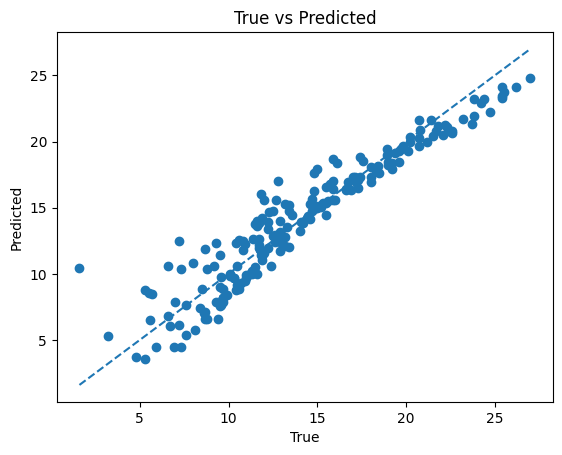

In [22]:
import matplotlib.pyplot as plt

# 预测
with torch.no_grad():
    y_pred = X @ w + b

# 转 numpy
y_true = y.numpy()
y_pred = y_pred.numpy()

# 画图
plt.scatter(y_true, y_pred)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("True vs Predicted")

# 画一条理想直线 y=x
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         linestyle='--')

plt.show()

# 残差图（Resedual）

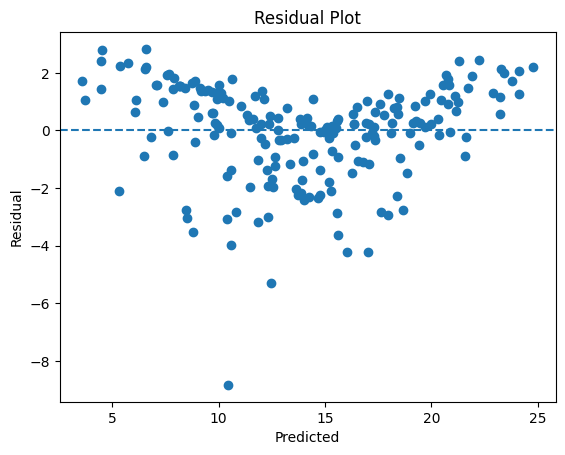

In [23]:
residuals = y_true - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

# 工程写法
##  Step 1：定义模型（替代 w, b）

In [24]:
import torch.nn as nn

model = nn.Linear(3, 1)

## Step 2：定义损失函数

In [25]:
criterion = nn.MSELoss()

## Step 3：定义优化器（重点）

In [26]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

## Step 4：训练循环（核心变化）

In [27]:
for epoch in range(1000):

    # 1️⃣ 前向传播
    y_pred = model(X)

    # 2️⃣ 计算 loss
    loss = criterion(y_pred, y)

    # 3️⃣ 清梯度（注意位置变了！）
    optimizer.zero_grad()

    # 4️⃣ 反向传播
    loss.backward()

    # 5️⃣ 更新参数
    optimizer.step()

    if epoch % 100 == 0:
        print(epoch, loss.item())

0 234.26101684570312
100 6.889090061187744
200 2.8668062686920166
300 2.7863855361938477
400 2.784226417541504
500 2.784132719039917
600 2.7841269969940186
700 2.7841262817382812
800 2.7841265201568604
900 2.7841262817382812


## Step 5：查看训练结果

In [28]:
print(model.weight)
print(model.bias)

Parameter containing:
tensor([[ 3.9291,  2.7991, -0.0226]], requires_grad=True)
Parameter containing:
tensor([14.0225], requires_grad=True)


# 可视化

In [29]:
with torch.no_grad():
    y_pred = model(X)

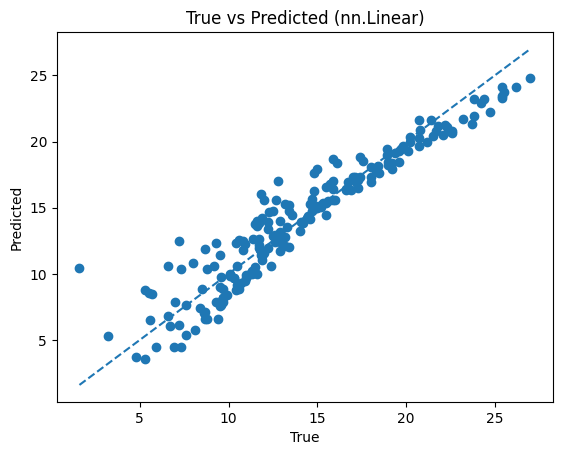

In [30]:
import matplotlib.pyplot as plt

# 转 numpy
y_true = y.numpy()
y_pred = y_pred.numpy()

plt.scatter(y_true, y_pred)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("True vs Predicted (nn.Linear)")

# 理想线
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         linestyle='--')

plt.show()

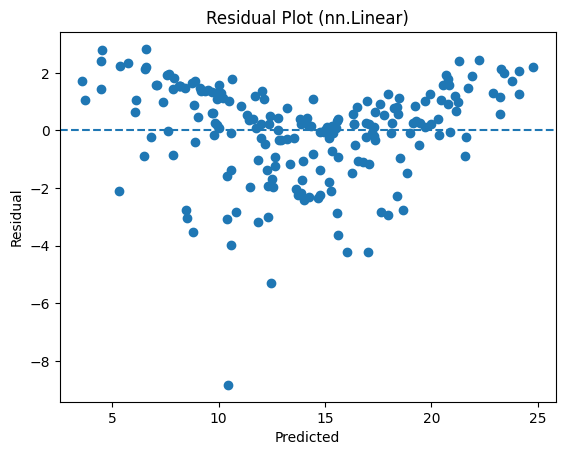

In [31]:
residuals = y_true - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot (nn.Linear)")
plt.show()